<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 4</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Modèles de régression</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : régression linéaire par méthode analytique et par descente de gradient, régression polynomiale, régularisation, régression logistique et régression logistique multinomiale. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scikit-learn` (≥ 1.8) et `statsmodels`.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scikit-learn', 'statsmodels')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]
ZONE    = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scikit-learn       1.9.0
statsmodels        0.14.6


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.1 : Génération de données bruitées</h3>

In [3]:
# Fixer la graine pour garantir la reproductibilité des résultats
np.random.seed(42)

# Définir le nombre d'observations
m = 100  

# Génération d'un ensemble de données X selon une distribution uniforme
X = np.random.rand(m, 1)

# Calcul des valeurs cibles sans bruit (modèle déterministe : y = 3x + 2)
y_o = 3 * X + 2

# Ajout d'un bruit gaussien centré pour simuler des données bruitées y
y = 3 * X + 2 + np.random.randn(m, 1)

# Tri croissant des observations (facilite le tracé des courbes)
ordre = np.argsort(X.ravel())
X, y_o, y = X[ordre], y_o[ordre], y[ordre]

<h3><span style="font-size: 30px">&#127924;</span> Figure : Données originales (a) et données bruitées (b)</h3>

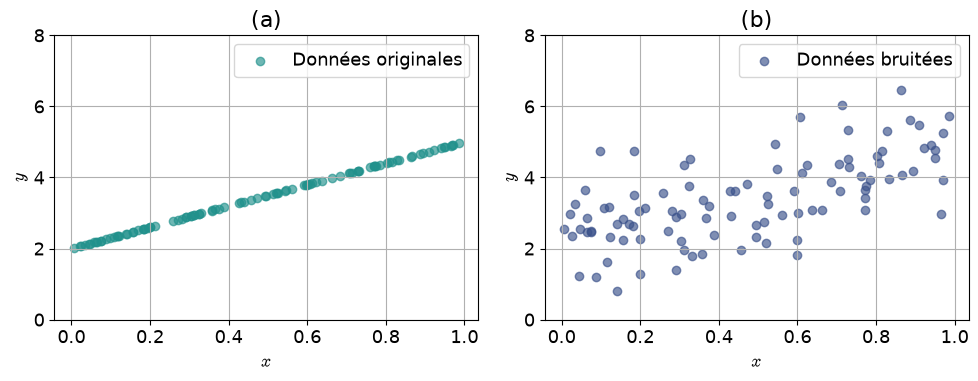

In [4]:
# Création des sous-graphiques
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Premier sous-graphe : données sans bruit
axs[0].scatter(X, y_o, color="#21918c", label="Données originales", alpha=0.65)
axs[0].set_xlabel("$x$")
axs[0].set_ylabel("$y$")
axs[0].set_ylim(0, 8)
axs[0].set_title("(a)")
axs[0].grid(True)
axs[0].legend()

# Deuxième sous-graphe : données avec bruit
axs[1].scatter(X, y, color="#3b528b", label="Données bruitées", alpha=0.65)
axs[1].set_xlabel("$x$")
axs[1].set_ylabel("$y$")
axs[1].set_ylim(0, 8)
axs[1].set_title("(b)")
axs[1].grid(True)
axs[1].legend()

# Optimisation de la mise en page
plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex1-DataEtBruit")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.2 : Méthode analytique par équation normale</h3>

In [5]:
# Ajout de x0 = 1 à chaque observation (pour inclure le biais)
X_b = np.c_[np.ones((m, 1)), X]  # Ajout de la colonne de 1 pour le biais

# Implémentation de l'équation normale
# Formule : theta = (X_b^T * X_b)^(-1) * X_b^T * y
theta_hat = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# S'assurer que theta_hat est un vecteur 1D pour éviter les erreurs d'affichage
theta_hat = theta_hat.ravel()

In [6]:
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Affichage des résultats
print("=" * 40)
print("Résultats de la régression linéaire")
print("=" * 40)
print(f"{'Paramètre':<15}{'Valeur'}")
print("-" * 40)
print(f"{'θ' + '0'.translate(SUP) + ' (biais)':<15}{theta_hat[0]:.6f}")
print(f"{'θ' + '1'.translate(SUP) + ' (pente)':<15}{theta_hat[1]:.6f}")
print("=" * 40)
print("L'équation de la droite est donc :")
print(f"y = {theta_hat[0]:.6f} + {theta_hat[1]:.6f} * x")
print("=" * 40)

Résultats de la régression linéaire
Paramètre      Valeur
----------------------------------------
θ₀ (biais)     2.215096
θ₁ (pente)     2.540227
L'équation de la droite est donc :
y = 2.215096 + 2.540227 * x


<h3><span style="font-size: 30px">&#127924;</span> Figure : Droite de régression obtenue par la méthode analytique</h3>

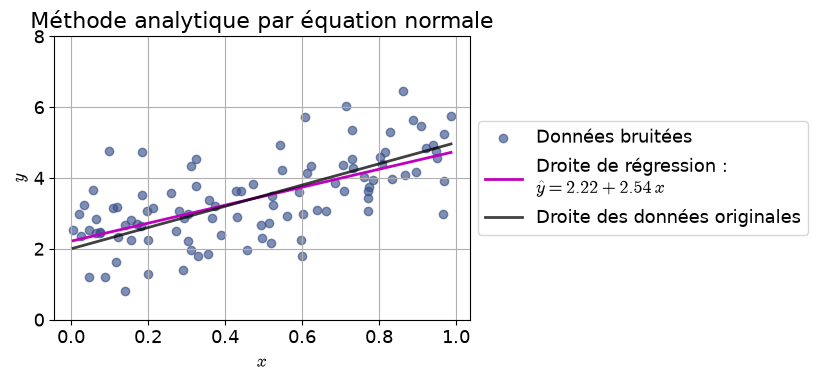

In [7]:
# Tracé de la droite de régression
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(X, y, color='#3b528b', label='Données bruitées', alpha=0.65)
ax.plot(X, X_b.dot(theta_hat), color='#bf00bf', linewidth=2,
        label=f'Droite de régression :\n'
              f'$\\hat{{y}} = {theta_hat[0]:.2f} + {theta_hat[1]:.2f}\\,x$')
ax.plot(X, y_o, color='black', linewidth=2, alpha=0.75,
        label='Droite des données originales')

# Étiquettes des axes
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Méthode analytique par équation normale')
ax.set_ylim(0, 8)
ax.grid(True)

plt.tight_layout()

# légende à droite
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex1-DteNormale")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.3 : Calcul de l'erreur absolue et de l'erreur relative des paramètres du modèle de régression</h3>

In [8]:
from sklearn.metrics import r2_score

# Vraies valeurs des paramètres (données générées avec y = 2 + 3x)
theta_true = np.array([2, 3])

# Erreur absolue
error_abs = np.abs(theta_hat - theta_true)

# Erreur relative (en %)
error_rel = np.abs((theta_hat - theta_true) / theta_true) * 100

# Calcul du coefficient de détermination R2
y_pred = X_b.dot(theta_hat.reshape(-1,1))
r2 = r2_score(y, y_pred)

In [9]:
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Affichage des résultats
print("=" * 55)
print("Évaluation du modèle de régression linéaire")
print("=" * 55)
print(f"{'Paramètre':<10}{'Erreur absolue':>20}{'Erreur relative (%)':>25}")
print("-" * 55)
print(f"{'θ' + '0'.translate(SUP) + ' (biais)':<10}{error_abs[0]:>20.6f}{error_rel[0]:>25.2f}")
print(f"{'θ' + '1'.translate(SUP) + ' (pente)':<10}{error_abs[1]:>20.6f}{error_rel[1]:>25.2f}")
print("=" * 55)
print()
print(f"Coefficient de détermination R² = {r2:.4f}")

Évaluation du modèle de régression linéaire
Paramètre       Erreur absolue      Erreur relative (%)
-------------------------------------------------------
θ₀ (biais)            0.215096                    10.75
θ₁ (pente)            0.459773                    15.33

Coefficient de détermination R² = 0.4121


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.4 : Méthode analytique par décomposition en valeurs singulières</h3>

In [10]:
from sklearn.linear_model import LinearRegression

# Initialisation du modèle
lin_reg = LinearRegression()

# Entraînement du modèle sur les données d'entrée X et les cibles y
lin_reg.fit(X, y)

# Extraction des valeurs des paramètres du modèle
intercept = lin_reg.intercept_.item()
coef = lin_reg.coef_.flatten()[0]

In [11]:
# Affichage des résultats
print("=" * 50)
print(" Résultats de la régression linéaire ")
print(" avec LinearRegression ")
print("=" * 50)

# Affichage sous forme de tableau structuré
print("{:<25} {:<20}".format("Paramètre", "Valeur"))  # En-tête du tableau
print("-" * 50)
print("{:<25} {:<20.6f}".format("Intercept (biais)", intercept))  # Affichage de l'intercept
print("{:<25} {:<20.6f}".format("Coefficient (pente)", coef))  # Affichage du coefficient

print("=" * 50)

# Affichage de l'équation de la droite ajustée
print("L'équation de la droite ajustée est :")
print(f"y = {intercept:.6f} + {coef:.6f} * x")  # Affichage de l'équation sous forme standard
print("=" * 50)

 Résultats de la régression linéaire 
 avec LinearRegression 
Paramètre                 Valeur              
--------------------------------------------------
Intercept (biais)         2.215096            
Coefficient (pente)       2.540227            
L'équation de la droite ajustée est :
y = 2.215096 + 2.540227 * x


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.5 : Initialisation des paramètres et des hyperparamètres pour une descente de gradient</h3>

In [12]:
np.random.seed(42)

# Hyperparamètres de la descente de gradient
learning_rate = 0.1  # Taux d'apprentissage
n_iterations  = 100  # Nombre d'itérations   

# Paramètres (theta_0 et theta_1)
theta = np.random.randn(2, 1)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.6 : Mise à jour des paramètres theta par descente de gradient ordinaire</h3>

In [13]:
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)  
    theta = theta - learning_rate * gradients

In [14]:
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Résultat final des paramètres après n itérations
print("=" * 50)
print("Résultats de la descente de gradient")
print("=" * 50)
print(f"{'Paramètre':<25}{'Valeur'}")
print("-" * 50)
print(f"{'θ' + '0'.translate(SUP) + ' (intercept)':<25}{theta[0][0]:.6f}")
print(f"{'θ' + '1'.translate(SUP) + ' (pente)':<25}{theta[1][0]:.6f}")
print("-" * 50)
print(f"Nombre d'itérations : {n_iterations}")
print("=" * 50)
print("L'équation de la droite ajustée est :")
print(f"y = {theta[0][0]:.6f} + {theta[1][0]:.6f} * x")
print("=" * 50)

Résultats de la descente de gradient
Paramètre                Valeur
--------------------------------------------------
θ₀ (intercept)           2.390256
θ₁ (pente)               2.194057
--------------------------------------------------
Nombre d'itérations : 100
L'équation de la droite ajustée est :
y = 2.390256 + 2.194057 * x


<h3><span style="font-size: 30px">&#127924;</span> Figure : Droite de régression obtenue par descente de gradient</h3>

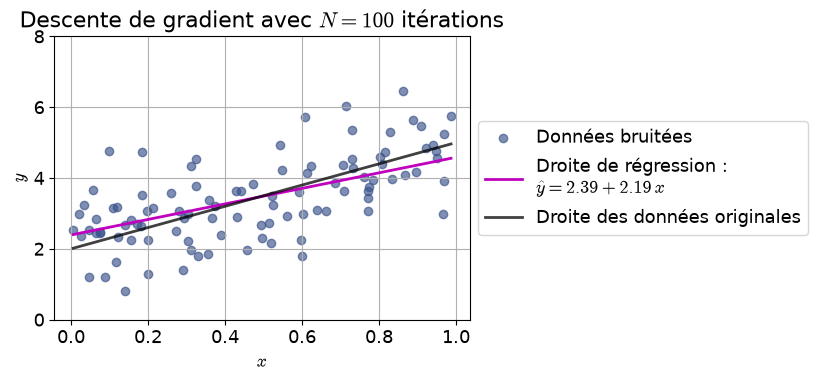

In [15]:
# Tracé de la droite de régression
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(X, y, color='#3b528b', label='Données bruitées', alpha=0.65)
ax.plot(X, X_b.dot(theta), color='#bf00bf', linewidth=2,
        label=f'Droite de régression :\n'
              f'$\\hat{{y}} = {theta[0][0]:.2f} + {theta[1][0]:.2f}\\,x$')
ax.plot(X, y_o, color='black', linewidth=2, alpha=0.75,
        label='Droite des données originales')

# Étiquettes des axes
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(f'Descente de gradient avec $N = {n_iterations}$ itérations')
ax.set_ylim(0, 8)
ax.grid(True)

plt.tight_layout()

# légende à droite
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex1-DteReg")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.7 : Représentation de la progression de la droite de régression en fonction du pas d'apprentissage $\eta$</h3>

In [16]:
def draw_theta(X, Y, eta, Theta, X_b, m, line_width, iteration, ax, draw_plot=True):
    # Calcul des gradients et mise à jour de Theta
    gradients = 2 / m * X_b.T.dot(X_b.dot(Theta) - Y)
    Theta = Theta - eta * gradients

    # Si draw_plot est True, on trace la droite de régression sur l'axe spécifique
    if draw_plot:
        ax.plot(X, X_b.dot(Theta), linestyle='-', linewidth=line_width,
                label=f'Itération {iteration}')

    return Theta

<h3><span style="font-size: 30px">&#127924;</span> Figure : Progression de la droite de régression selon le taux d'apprentissage</h3>

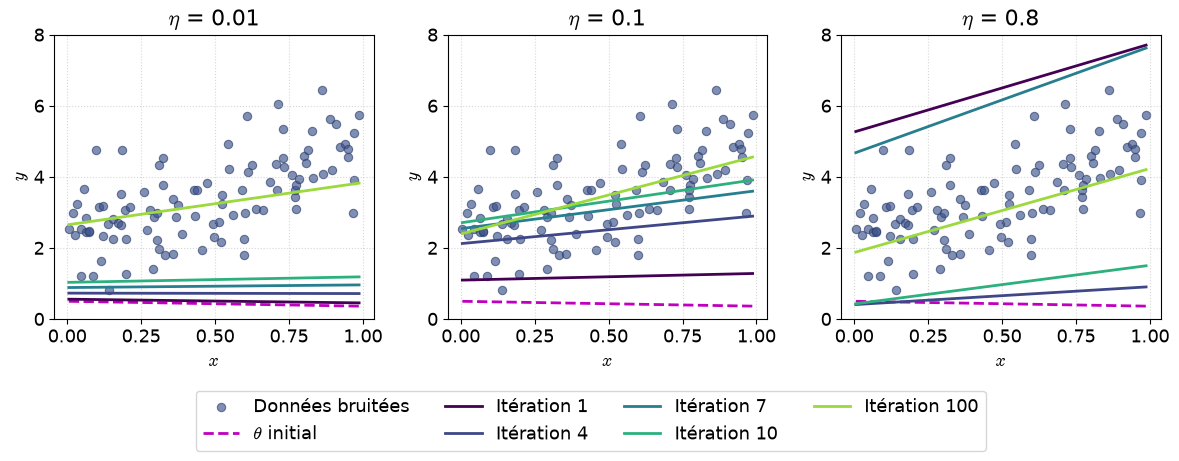


Valeurs finales de theta pour chaque valeur de eta :

Eta        Theta_0         Theta_1        
----------------------------------------
0.01       2.648126        1.189265       
0.1        2.390256        2.194057       
0.8        1.868200        2.364689       


In [17]:
# Initialisation des données et des hyperparamètres
np.random.seed(42)
m = 100  # Nombre d'observations
n_iterations = 100  # Nombre d'itérations
X_b = np.c_[np.ones((m, 1)), X]  # Ajout de x0 = 1 à chaque observation

list_eta = [0.01, 0.1, 0.8]  # Différents pas d'apprentissage
theta_init = np.random.randn(2, 1)  # Initialisation aléatoire de Theta
# Liste pour stocker les résultats
theta_results = []

# Création de la figure pour les visualisations
fig = plt.figure(figsize=(12, 4))

# Boucle sur chaque valeur de pas d'apprentissage (eta)
for i, eta in enumerate(list_eta, start=1):
    theta = theta_init.copy()  # Copie de theta_init pour chaque eta

    ax = plt.subplot(1, 3, i)  # Création des sous-graphiques
    plt.scatter(X, y, color=BLEU, edgecolors=BORD[BLEU], linewidths=0.8,
                label="Données bruitées", alpha=0.65)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(f'$\\eta$ = {eta}')
    plt.ylim(0, 8)  # Limites identiques pour les trois panneaux

    # Tracé de la droite initiale (Theta initial)
    plt.plot(X, X_b.dot(theta), linestyle='--', color=MAGENTA, linewidth=2,
             label=r'$\theta$ initial')

    # Dégradé viridis pour les droites successives
    plt.gca().set_prop_cycle(color=plt.cm.viridis(np.linspace(0, 0.85, 5)))

    # Boucle d'optimisation des paramètres avec descente de gradient
    for iteration in range(n_iterations):
        # Traçage pour les 10 premières itérations et la dernière
        if iteration < 10 and iteration % 3 == 0 or iteration == n_iterations - 1:
            draw_plot = True
        else:
            draw_plot = False

        theta = draw_theta(X, y, eta, theta, X_b, m, 2, iteration + 1, plt, draw_plot)

    plt.grid(True, linestyle=':', alpha=0.5)

    # Stockage des résultats
    theta_results.append([eta, theta[0][0], theta[1][0]])

# Affichage final des graphiques
plt.tight_layout()

# Légende commune aux trois panneaux, placée sous la figure
handles, labels = fig.axes[0].get_legend_handles_labels()
ncol = int(np.ceil(len(labels) / 2))      # répartition sur deux lignes
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=ncol)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex1-DteReg1")

plt.show()

# Affichage des résultats de theta
print("\nValeurs finales de theta pour chaque valeur de eta :\n")
print("{:<10} {:<15} {:<15}".format("Eta", "Theta_0", "Theta_1"))
print("-" * 40)
for eta, theta_0, theta_1 in theta_results:
    print(f"{eta:<10} {theta_0:<15.6f} {theta_1:<15.6f}")

<h3><span style="font-size: 30px">&#127924;</span>Animation de la descente de gradient selon le pas d'apprentissage </h3>

![Animation de la régression multiple](Figures/Chap4_animation_multi_regression.gif)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.8 : Descente de gradient stochastique basée sur SGDRegressor</h3>

In [18]:
from sklearn.linear_model import SGDRegressor 

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42) 
sgd_reg.fit(X, y.ravel())

,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.1
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0


In [19]:
# Affichage des résultats de la descente de gradient stochastique
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

print("=" * 55)
print("Résultats de la descente de gradient stochastique (SGD)")
print("=" * 55)
print(f"{'Paramètre':<20}\t{'Valeur'}")
print("-" * 55)
print(f"{'θ' + '0'.translate(SUP) + ' (biais)':<20}\t{sgd_reg.intercept_[0]:.6f}")
print(f"{'θ' + '1'.translate(SUP) + ' (pente)':<20}\t{sgd_reg.coef_[0]:.6f}")
print("=" * 55)
print(f"Convergence en {sgd_reg.n_iter_} époques")

Résultats de la descente de gradient stochastique (SGD)
Paramètre           	Valeur
-------------------------------------------------------
θ₀ (biais)          	2.273551
θ₁ (pente)          	2.447724
Convergence en 17 époques


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.9 : Implémentation de la fonction de descente de gradient stochastique</h3>

In [20]:
def stochastic_gradient_descent(X, y, theta, learning_rate, n_iterations, random_state=None):
    m = len(X)
    rng = np.random.RandomState(random_state)

    for iteration in range(n_iterations):
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]  # Sélectionner une ligne
            yi = y_shuffled[i:i+1]  # Sélectionner sa sortie

            # Calcul du gradient (pour une seule observation) et mise à jour
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)  
            theta = theta - learning_rate * gradients
    return theta

In [21]:
# Initialisation des données et des hyperparamètres
np.random.seed(42)

# Ajouter la colonne de biais (intercept)
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Ajout d'une colonne de 1 pour l'intercept

# Paramètres d'initialisation
theta = np.random.randn(2, 1)  # Initialisation aléatoire des paramètres (theta_0 et theta_1)
learning_rate = 0.1  # Taux d'apprentissage
n_iterations = 1000  # Nombre maximal d'itérations

# Exécuter la descente de gradient stochastique
theta_final = stochastic_gradient_descent(X_b, y, theta, learning_rate, n_iterations, random_state=42)

In [22]:
# Affichage des résultats
intercept_ = theta_final[0][0]  # Intercept (Theta_0)
coef_ = theta_final[1][0]       # Coefficient (Theta_1)

print("=" * 60)
print("Résultats de la descente de gradient stochastique (manuelle)")
print("=" * 60)
print(f"{'Paramètre':<30}\t{'Valeur'}")
print("-" * 60)
print(f"{'Theta_0 (intercept)':<30}\t{intercept_:.4f}")
print(f"{'Theta_1 (coefficient)':<30}\t{coef_:.4f}")
print("=" * 60)

Résultats de la descente de gradient stochastique (manuelle)
Paramètre                     	Valeur
------------------------------------------------------------
Theta_0 (intercept)           	2.2480
Theta_1 (coefficient)         	2.2122


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.10 : Implémentation de la fonction de descente de gradient par mini-lots</h3>

In [23]:
def mini_batch_gradient_descent(X, y, theta, learning_rate, n_iterations, batch_size, random_state=None):
    m = len(X)
    rng = np.random.RandomState(random_state)

    for iteration in range(n_iterations):
        # Mélanger les données au début de chaque époque
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Parcourir les données par mini-lots
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Calculer le gradient pour le mini-lot et mise à jour
            gradients = 2 / len(X_batch) * X_batch.T.dot(X_batch.dot(theta) - 
                                                         y_batch)
            theta = theta - learning_rate * gradients
    return theta

In [24]:
# Initialisation des données et des hyperparamètres
np.random.seed(42)
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Ajout d'une colonne de 1 pour l'intercept
theta = np.random.randn(2, 1)  # Initialisation aléatoire de theta
learning_rate = 0.1
n_iterations = 1000
batch_size   = 16  # Taille des mini-lots

# Exécuter la descente de gradient par mini-lots
theta_final = mini_batch_gradient_descent(X_b, y, theta, learning_rate, n_iterations, batch_size, random_state=42)

In [25]:
# Affichage des résultats
intercept_manual = theta_final[0][0]
coef_manual = theta_final[1][0]

print("=" * 65)
print(f" Résultats après {n_iterations} itérations avec mini_batch_gradient_descent ")
print("=" * 65)
print("{:<25} {:>20}".format("Paramètre", "Valeur"))
print("-" * 65)
print("{:<25} {:>20.4f}".format("Theta_0 (intercept)", intercept_manual))
print("{:<25} {:>20.4f}".format("Theta_1 (pente)", coef_manual))
print("=" * 65)
print("L'équation de la droite ajustée est :")
print(f"y = {intercept_manual:.4f} + {coef_manual:.4f} * x")
print("=" * 65)

 Résultats après 1000 itérations avec mini_batch_gradient_descent 
Paramètre                               Valeur
-----------------------------------------------------------------
Theta_0 (intercept)                     2.1597
Theta_1 (pente)                         2.5511
L'équation de la droite ajustée est :
y = 2.1597 + 2.5511 * x


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.11 : Évaluation du même modèle par partition apprentissage/test et par validation croisée</h3>

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
modele = LinearRegression().fit(X_tr, y_tr)

# Erreur sur les données jamais vues
rmse_te = np.sqrt(mean_squared_error(y_te, modele.predict(X_te)))
r2_te = r2_score(y_te, modele.predict(X_te))

# Les mêmes quantités sur les données d'entraînement, pour comparaison
rmse_tr = np.sqrt(mean_squared_error(y_tr, modele.predict(X_tr)))
r2_tr = r2_score(y_tr, modele.predict(X_tr))

# Validation croisée 5-fold sur l'ensemble des données
scores = cross_val_score(LinearRegression(), X, y, cv=5,
                         scoring="neg_root_mean_squared_error")

In [27]:
# Affichage des résultats
rmse_cv = -scores

print("=" * 50)
print("Comparaison entraînement / test")
print("=" * 50)
print(f"{'Métrique':<18}{'Entraînement':<18}{'Test'}")
print(f"{'RMSE':<18}{rmse_tr:<18.4f}{rmse_te:.4f}")
print(f"{'R2':<18}{r2_tr:<18.4f}{r2_te:.4f}")
# print()
print("=" * 50)
print("Validation croisée (5-fold)")
print("=" * 50)
entetes = [f"Fold {i}" for i in range(1, len(rmse_cv) + 1)]
print("Folds".ljust(10) + "".join(e.ljust(8) for e in entetes))
print("RMSE".ljust(10) + "".join(f"{v:.4f}".ljust(8) for v in rmse_cv))
print("-" * 50)
print(" " * 28 + f"{'Moyenne':<12}{rmse_cv.mean():.4f}")
print(" " * 28 + f"{'Écart-type':<12}{rmse_cv.std():.4f}")
print("=" * 50)

Comparaison entraînement / test
Métrique          Entraînement      Test
RMSE              0.9085            0.8564
R2                0.4165            0.3667
Validation croisée (5-fold)
Folds     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  
RMSE      0.9582  0.9253  0.8777  1.0092  0.9384  
--------------------------------------------------
                            Moyenne     0.9418
                            Écart-type  0.0429


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.12 : Génération de données polynomiales</h3>

In [28]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y_o = 0.5 * X**2 + X + 2                       # Données originales
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1) # Données bruitées 

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.13 : Transformation polynomiale des caractéristiques</h3>

In [29]:
from sklearn.preprocessing import PolynomialFeatures

# Transformation polynomiale
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Affichage des dimensions
print("Dimension de X:", X.shape)
print("Dimension de X_poly:", X_poly.shape)

Dimension de X: (100, 1)
Dimension de X_poly: (100, 2)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.14 : Entraînement du modèle de régression polynomiale</h3>

In [30]:
from sklearn.linear_model import LinearRegression

# Création et ajustement du modèle de régression linéaire
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# Extraction des paramètres du modèle
intercept = lin_reg.intercept_[0]
coefficients = lin_reg.coef_.flatten()

In [31]:
# Paramètres du modèle polynomial
print("=" * 38)
print("Paramètres du modèle polynomial")
print("=" * 38)

print(f"{'Paramètre':<15}{'Terme':<15}{'Valeur'}")
print("-" * 38)

print(f"{'θ₀':<15}{'Constante':<15}{intercept:.4f}")

indices = ["₁", "₂", "₃", "₄", "₅", "₆", "₇", "₈", "₉"]
exposants = ["¹", "²", "³", "⁴", "⁵", "⁶", "⁷", "⁸", "⁹"]

for i, c in enumerate(coefficients, start=1):
    parametre = f"θ{indices[i-1]}"
    terme = "x" if i == 1 else f"x{exposants[i-1]}"
    print(f"{parametre:<15}{terme:<15}{c:.4f}")

print("=" * 38)

Paramètres du modèle polynomial
Paramètre      Terme          Valeur
--------------------------------------
θ₀             Constante      1.7813
θ₁             x              0.9337
θ₂             x²             0.5646


<h3><span style="font-size: 30px">&#127924;</span> Figure : Régression polynomiale de degré $p=2$, données originales, données bruitées et modèle ajusté</h3>

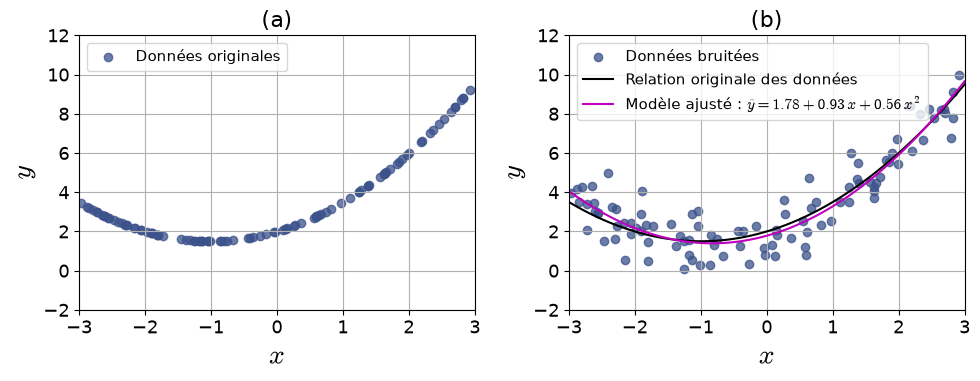

In [32]:
# Génération de nouvelles données pour la prédiction
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

# Relation originale, sans bruit
y_new_o = 0.5 * X_new**2 + X_new + 2
# Équation du modèle ajusté, affichée dans la légende
equation = (f"Modèle ajusté : $\\hat{{y}} = {intercept:.2f} + "
            f"{coefficients[0]:.2f}\\,x + {coefficients[1]:.2f}\\,x^2$")

# Création de la figure à deux panneaux
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sous-graphe (a) : données originales
axes[0].scatter(X, y_o, color="#3b528b", label="Données originales", alpha=0.75)
axes[0].set_title("(a)", fontsize=16)

# Sous-graphe (b) : modèle polynomial ajusté
axes[1].scatter(X, y, color="#3b528b", label="Données bruitées", alpha=0.75)
axes[1].plot(X_new, y_new_o, "k-", linewidth=1.5, label="Relation originale des données ")
axes[1].plot(X_new, y_new, "m-", linewidth=1.5, label=equation)
axes[1].set_title("(b)", fontsize=16)
# Paramètres communs aux deux panneaux
for ax in axes:
    ax.set_xlabel("$x$", fontsize=20)
    ax.set_ylabel("$y$", fontsize=20)
    ax.set_xlim(-3, 3)
    # ax.set_ylim(-0.5, 10.5)
    ax.set_ylim(-2, 12)
    ax.tick_params(axis="both")
    ax.legend(loc="upper left", fontsize=11)
    ax.grid(True)
    
# Optimisation de la mise en page
fig.tight_layout()
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex-Poly2")

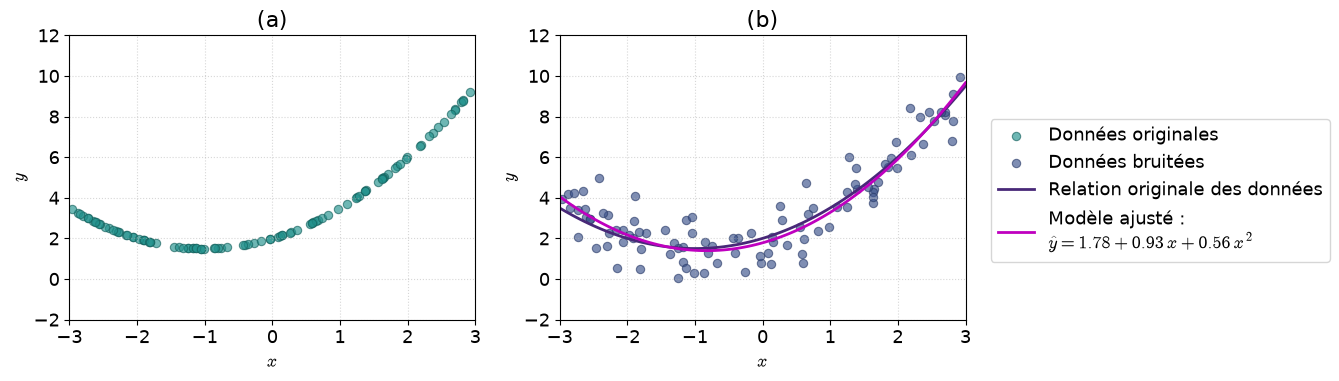

In [33]:
# Génération de nouvelles données pour la prédiction
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

# Relation originale, sans bruit
y_new_o = 0.5 * X_new**2 + X_new + 2

# Équation du modèle ajusté, affichée dans la légende
equation = (f"Modèle ajusté :\n$\\hat{{y}} = {intercept:.2f} + "
            f"{coefficients[0]:.2f}\\,x + {coefficients[1]:.2f}\\,x^2$")

# Création de la figure à deux panneaux
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sous-graphe (a) : données originales
axes[0].scatter(X, y_o, color=SARCELLE, edgecolors=BORD[SARCELLE],
                linewidths=0.8, alpha=0.65, label="Données originales")
axes[0].set_title("(a)")

# Sous-graphe (b) : modèle polynomial ajusté
axes[1].scatter(X, y, color=BLEU, edgecolors=BORD[BLEU],
                linewidths=0.8, alpha=0.65, label="Données bruitées")
axes[1].plot(X_new, y_new_o, color=VIOLET, linewidth=2,
             label="Relation originale des données")
axes[1].plot(X_new, y_new, color=MAGENTA, linewidth=2, label=equation)
axes[1].set_title("(b)")

# Paramètres communs aux deux panneaux
for ax in axes:
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 12)
    ax.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()

# Légende unique, à droite de la figure
handles = (axes[0].get_legend_handles_labels()[0]
           + axes[1].get_legend_handles_labels()[0])
labels  = (axes[0].get_legend_handles_labels()[1]
           + axes[1].get_legend_handles_labels()[1])

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex-Poly2")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Modèles polynomiaux de degré $p=1$ (sous-apprentissage) et $p=30$ (surapprentissage)</h3>

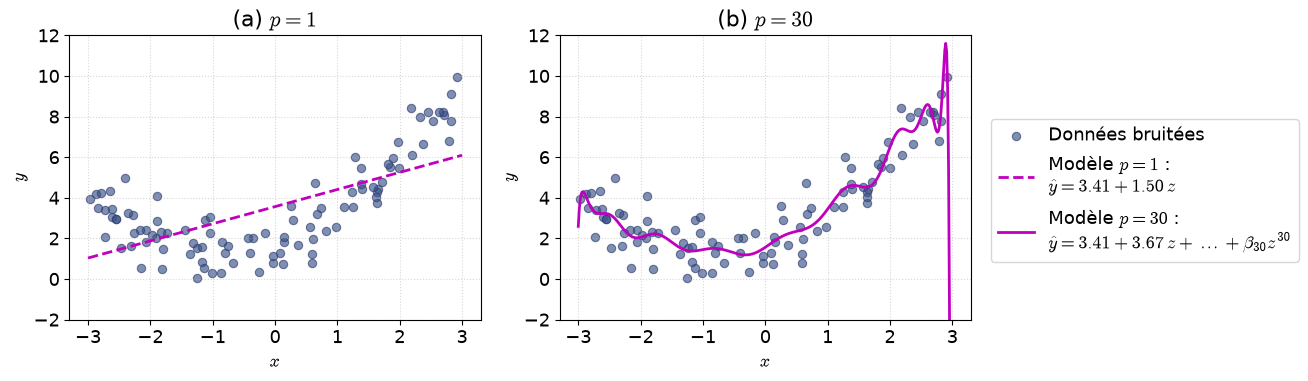

In [34]:
# Modèles polynomiaux de degré p = 1 et p = 30
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

styles = {1: '--', 30: '-'}     # tiretés pour p = 1, continu pour p = 30

for ax, p, panneau in zip(axes, [1, 30], ["(a)", "(b)"]):
    modele_p = make_pipeline(PolynomialFeatures(degree=p, include_bias=False),
                             StandardScaler(),
                             LinearRegression())
    modele_p.fit(X, y.ravel())

    # Coefficients du modèle ajusté (sur variables standardisées)
    lin = modele_p.named_steps['linearregression']
    b0, b1 = lin.intercept_, lin.coef_[0]

    if p == 1:
        eq = f"$\\hat{{y}} = {b0:.2f} + {b1:.2f}\\,z$"
    else:
        eq = f"$\\hat{{y}} = {b0:.2f} + {b1:.2f}\\,z + \\dots + \\beta_{{{p}}}z^{{{p}}}$"

    ax.scatter(X, y, color=BLEU, edgecolors=BORD[BLEU], linewidths=0.8,
               alpha=0.65, label='Données bruitées' if p == 1 else None)
    ax.plot(X_plot, modele_p.predict(X_plot), color=MAGENTA,
            linestyle=styles[p], linewidth=2,
            label=f"Modèle $p = {p}$ :\n{eq}")

    ax.set_title(f"{panneau} $p = {p}$")
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_ylim(-2, 12)
    ax.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()

# Légende unique, à droite de la figure
handles = (axes[0].get_legend_handles_labels()[0]
           + axes[1].get_legend_handles_labels()[0])
labels  = (axes[0].get_legend_handles_labels()[1]
           + axes[1].get_legend_handles_labels()[1])

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex-Poly3")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : $R^2$ d'ajustement et $R^2$ de test en fonction du degré $p$ du polynôme</h3>

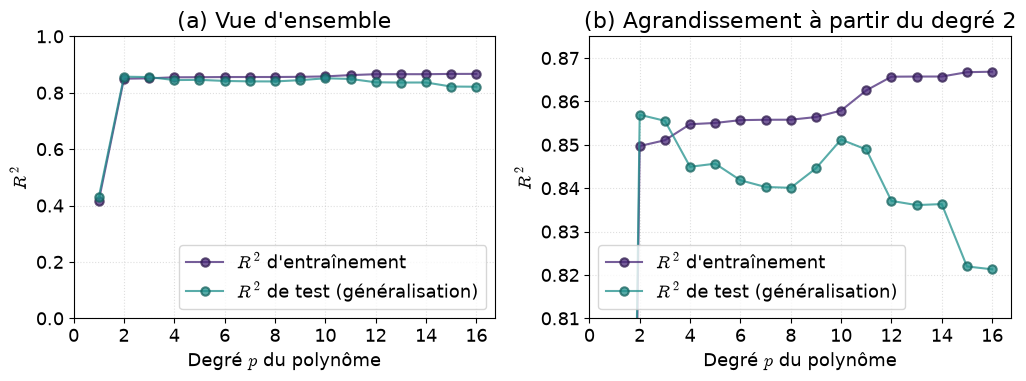

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# X et y sont ici les données quadratiques bruitées de l'extrait 4.13
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

degres = list(range(1, 17))
r2_tr, r2_te = [], []
for p in degres:
    mod = make_pipeline(PolynomialFeatures(degree=p, include_bias=False),
                        StandardScaler(), LinearRegression())
    mod.fit(X_tr, y_tr.ravel())
    r2_tr.append(r2_score(y_tr, mod.predict(X_tr)))
    r2_te.append(r2_score(y_te, mod.predict(X_te)))


def trace(ax, deg, tr, te, ms=6):
    ax.plot(deg, tr, 'o-', color=VIOLET, markersize=ms,
            markeredgewidth=1.5, markeredgecolor=BORD[VIOLET], alpha=0.75,
            label=r"$R^2$ d'entraînement")
    ax.plot(deg, te, 'o-', color=SARCELLE, markersize=ms,
            markeredgewidth=1.5, markeredgecolor=BORD[SARCELLE], alpha=0.75,
            label=r"$R^2$ de test (généralisation)")
    ax.set_xlabel("Degré $p$ du polynôme")
    ax.set_ylabel(r"$R^2$")
    ax.set_xticks(range(0, 17, 2))
    ax.grid(alpha=0.4, linestyle=':')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.0))

# (a) vue d'ensemble : les deux R2 sur l'échelle complète
trace(ax1, degres, r2_tr, r2_te)
ax1.set_ylim(0, 1)
ax1.legend(loc='lower right')
ax1.set_title("(a) Vue d'ensemble")

# (b) agrandissement : l'écart entre entraînement et test se creuse
trace(ax2, degres, r2_tr, r2_te)
ax2.set_ylim(0.81, 0.875)
ax2.legend(loc='lower left')
ax2.set_title("(b) Agrandissement à partir du degré 2")

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-R2Degre")

plt.show()

In [36]:
print("=" * 53)
print("Valeurs utilisées dans la figure:")
print("=" * 53)
print(f"{'Degré':<8}{'R2 entraînement':<20}{'R2 test':<15}{'Écart':<10}")
print("-" * 53)

for p, tr, te in zip(degres, r2_tr, r2_te):
    print(f"{p:<8}{tr:<20.4f}{te:<15.4f}{tr - te:<10.4f}")

print("=" * 53)

# Valeurs particulièrement utiles pour le texte
i_max_test = max(range(len(r2_te)), key=lambda i: r2_te[i])
i_chute_test = min(range(1, len(r2_te)),
                   key=lambda i: r2_te[i] - r2_te[i - 1])

print(f"R2 entraînement au degré 2  : {r2_tr[1]:.4f}")
print(f"R2 entraînement au degré 16 : {r2_tr[15]:.4f}")
print(f"Meilleur R2 de test         : {r2_te[i_max_test]:.4f} "
      f"au degré {degres[i_max_test]}")
print(f"R2 de test au degré 16      : {r2_te[15]:.4f}")
print(f"Écart au degré 2            : {r2_tr[1] - r2_te[1]:.4f}")
print(f"Écart au degré 16           : {r2_tr[15] - r2_te[15]:.4f}")
print(f"Plus forte chute du R2 test : degré {degres[i_chute_test - 1]} "
      f"-> {degres[i_chute_test]}")
print(f"                              {r2_te[i_chute_test - 1]:.4f} "
      f"-> {r2_te[i_chute_test]:.4f}")

Valeurs utilisées dans la figure:
Degré   R2 entraînement     R2 test        Écart     
-----------------------------------------------------
1       0.4172              0.4297         -0.0125   
2       0.8497              0.8569         -0.0072   
3       0.8510              0.8555         -0.0045   
4       0.8547              0.8449         0.0098    
5       0.8550              0.8456         0.0094    
6       0.8557              0.8418         0.0139    
7       0.8558              0.8403         0.0155    
8       0.8558              0.8401         0.0157    
9       0.8564              0.8446         0.0118    
10      0.8579              0.8512         0.0067    
11      0.8625              0.8489         0.0136    
12      0.8657              0.8371         0.0286    
13      0.8657              0.8361         0.0296    
14      0.8657              0.8363         0.0294    
15      0.8667              0.8220         0.0448    
16      0.8668              0.8213         0.045

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.15 : Comparaison de modèles polynomiaux de degré 10 : sans régularisation, ridge et lasso</h3>

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

modeles = {"Sans régularisation": LinearRegression(),
           "Ridge (alpha=1)":     Ridge(alpha=1),
           "Lasso (alpha=1)":     Lasso(alpha=1)}

for nom, reg in modeles.items():
    modele = make_pipeline(
        PolynomialFeatures(degree=10, include_bias=False),
        StandardScaler(),
        reg)
    modele.fit(X, y.ravel())

<h3><span style="font-size: 30px">&#127924;</span> Figure : Effet de la régularisation sur un polynôme de degré 10</h3>

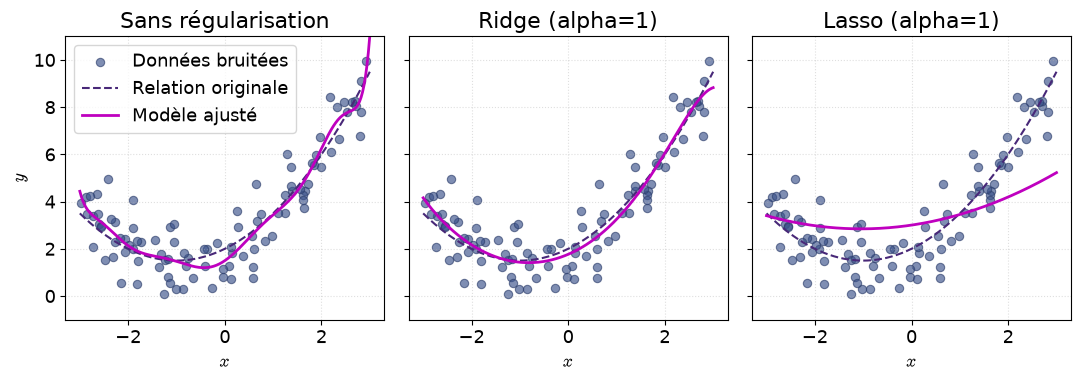

In [38]:
X_trace = np.linspace(-3, 3, 400).reshape(-1, 1)
y_vrai = 0.5 * X_trace**2 + X_trace + 2

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

for ax, (nom, reg) in zip(axes, modeles.items()):
    modele = make_pipeline(PolynomialFeatures(degree=10, include_bias=False),
                           StandardScaler(), reg)
    modele.fit(X, y.ravel())

    ax.scatter(X, y, color=BLEU, edgecolors=BORD[BLEU], linewidths=0.8,
               alpha=0.65, label='Données bruitées')
    ax.plot(X_trace, y_vrai, color=VIOLET, linestyle='--', lw=1.5,
            label='Relation originale')
    ax.plot(X_trace, modele.predict(X_trace), color=MAGENTA, lw=2,
            label='Modèle ajusté')

    ax.set_title(nom)
    ax.set_xlabel('$x$')
    ax.set_ylim(-1, 11)
    ax.grid(alpha=0.4, linestyle=':')

axes[0].set_ylabel('$y$')
axes[0].legend()

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-Ex-Regul")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Fonction logistique (sigmoïde)</h3>

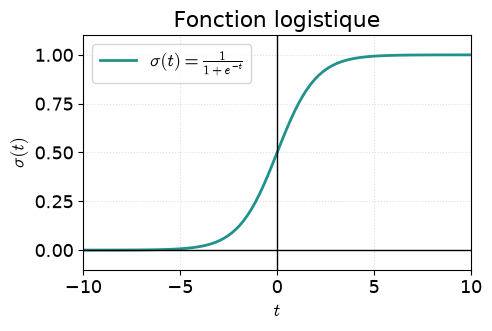

In [39]:
# Définition de la fonction logistique
def logistic_function(t):
    return 1 / (1 + np.exp(-t))

# Génération des valeurs de t
t = np.linspace(-10, 10, 100)

# Calcul des valeurs de la fonction logistique
sigma_t = logistic_function(t)

# Création du graphique avec une taille optimisée
fig, ax = plt.subplots(figsize=(5, 3.5))

# Tracé de la fonction logistique
ax.plot(t, sigma_t, color=SARCELLE, linewidth=2,
        label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")

# Ajout des axes de référence
ax.axhline(y=0, color='black', linewidth=1)
ax.axvline(x=0, color='black', linewidth=1)

# Paramètres des axes
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\sigma(t)$")
ax.set_title("Fonction logistique")

# Configuration de la légende
ax.legend(loc="upper left")

# Configuration des limites et du quadrillage
ax.grid(alpha=0.4, linestyle=':')
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(-10, 10)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-LogitPlot")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.16 : Lecture des données Iris</h3>

In [40]:
import pandas as pd
from sklearn import datasets

# Chargement du jeu de données Iris depuis la bibliothèque scikit-learn
iris = datasets.load_iris()

# Conversion des données en DataFrame avec les noms de caractéristiques comme en-têtes de colonnes
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Ajout d'une colonne 'target' représentant l'espèce (0: setosa, 1: versicolor, 2: virginica)
iris_df['target'] = iris.target

In [41]:
display(iris_df.head(10))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


<h3><span style="font-size: 30px">&#127924;</span> Figure : Dispersion du pétale pour les trois espèces</h3>

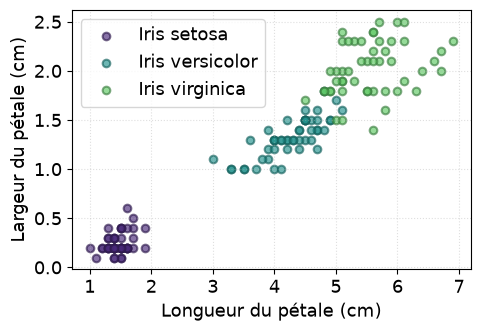

In [42]:
# Dispersion de la largeur du pétale en fonction de sa longueur (3 classes)
fig, ax = plt.subplots(figsize=(5, 3.5))

couleurs = [VIOLET, SARCELLE, VERT]  # setosa, versicolor, virginica

for cls, nom, coul in zip([0, 1, 2], iris.target_names, couleurs):
    idx = iris_df['target'] == cls
    ax.scatter(iris_df.loc[idx, 'petal length (cm)'],
               iris_df.loc[idx, 'petal width (cm)'],
               s=30, alpha=0.65, color=coul, edgecolors=BORD[coul],
               linewidths=1.5, label=f"Iris {nom}")

ax.set_xlabel('Longueur du pétale (cm)')
ax.set_ylabel('Largeur du pétale (cm)')
ax.legend(loc="upper left")
ax.grid(alpha=0.4, linestyle=':')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureDispersion3C")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.17 : Transformation des labels en deux classes</h3>

In [43]:
X = iris_df[['petal length (cm)']].values
y = (iris_df['target'] == 2).astype(int).values 

<h3><span style="font-size: 30px">&#127924;</span> Figure : Dispersion du pétale pour les deux classes</h3>

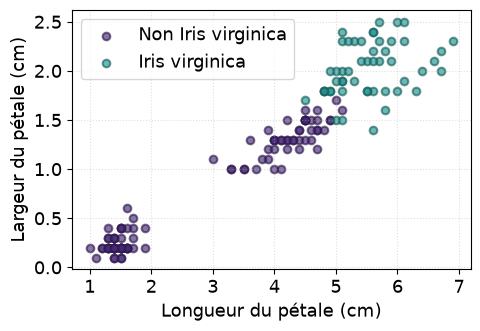

In [44]:
# Dispersion du pétale après regroupement en deux classes
y2 = (iris_df['target'] == 2).astype(int).values

fig, ax = plt.subplots(figsize=(5, 3.5))

for val, nom, coul in [(0, "Non Iris virginica", VIOLET),
                       (1, "Iris virginica", SARCELLE)]:
    idx = (y2 == val)
    ax.scatter(iris_df.loc[idx, 'petal length (cm)'],
               iris_df.loc[idx, 'petal width (cm)'],
               s=30, color=coul, edgecolors=BORD[coul], linewidths=1.5,
               label=nom, alpha=0.65)

ax.set_xlabel('Longueur du pétale (cm)')
ax.set_ylabel('Largeur du pétale (cm)')
ax.legend(loc="upper left")
ax.grid(alpha=0.4, linestyle=':')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureDispersion2CR")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Dispersion du pétale : trois espèces (a) et deux classes (b)</h3>

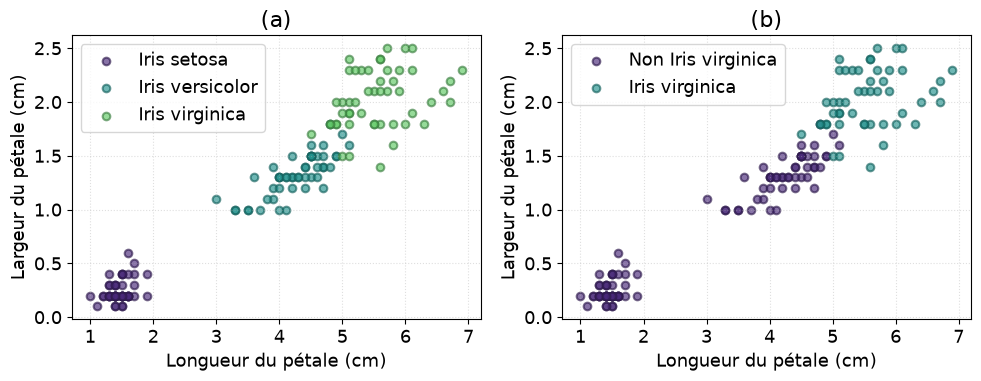

In [45]:
# Dispersion du pétale : trois espèces (a) et deux classes (b)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sous-graphe (a) : les trois espèces
couleurs = [VIOLET, SARCELLE, VERT]  # setosa, versicolor, virginica

for cls, nom, coul in zip([0, 1, 2], iris.target_names, couleurs):
    idx = iris_df['target'] == cls
    axes[0].scatter(iris_df.loc[idx, 'petal length (cm)'],
                    iris_df.loc[idx, 'petal width (cm)'],
                    s=30, alpha=0.65, color=coul, edgecolors=BORD[coul],
                    linewidths=1.5, label=f"Iris {nom}")

axes[0].set_title("(a)")
axes[0].legend(loc="upper left")

# Sous-graphe (b) : regroupement en deux classes
y2 = (iris_df['target'] == 2).astype(int).values

for val, nom, coul, bord in [(0, "Non Iris virginica", VIOLET, BORD[VIOLET]),
                             (1, "Iris virginica", SARCELLE, BORD[SARCELLE])]:
    idx = (y2 == val)
    axes[1].scatter(iris_df.loc[idx, 'petal length (cm)'],
                    iris_df.loc[idx, 'petal width (cm)'],
                    s=30, alpha=0.65, color=coul, edgecolors=bord,
                    linewidths=1.5, label=nom)

axes[1].set_title("(b)")
axes[1].legend(loc="upper left")

# Paramètres communs aux deux panneaux
for ax in axes:
    ax.set_xlabel('Longueur du pétale (cm)')
    ax.set_ylabel('Largeur du pétale (cm)')
    ax.grid(alpha=0.4, linestyle=':')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureDispersion_3C_2C")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Longueur du pétale pour les deux classes</h3>

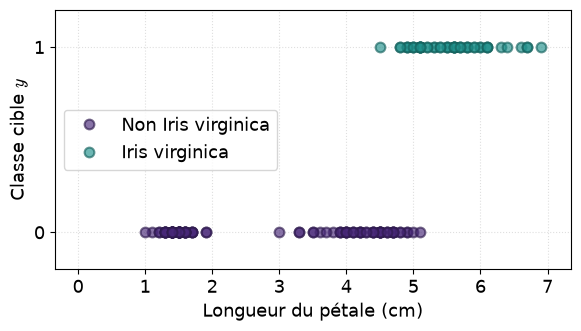

In [46]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(6, 3.5))

# Tracer les points de données pour chaque classe avec couleurs et bordures distinctes
for val, nom, coul in [(0, "Non Iris virginica", VIOLET),
                       (1, "Iris virginica", SARCELLE)]:
    idx = (y == val)
    ax.plot(X[idx, 0], y[idx], "o", alpha=0.65, color=coul, markersize=7,
            markeredgewidth=1.5, markeredgecolor=BORD[coul], label=nom)

# Paramètres des axes
ax.set_xlabel("Longueur du pétale (cm)")
ax.set_ylabel("Classe cible $y$")

# Limites et graduations des axes
ax.set_xticks(range(8))
ax.set_xlim(-0.35, 7.35)
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 1])

# Légende et grille
ax.legend(loc="center left")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureDispersionPetalLength")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.18 : Entraînement du modèle de régression logistique</h3>

In [47]:
from sklearn.linear_model import LogisticRegression

# Création et entraînement du modèle de régression logistique
log_reg = LogisticRegression()
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [48]:
# Récupération des paramètres
intercept = log_reg.intercept_[0]
coefficient = log_reg.coef_[0][0]
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Affichage des résultats
print("=" * 55)
print("Régression logistique binaire (Virginica vs autres)")
print("=" * 55)
print(f"{'Paramètre':<8}\t{'Terme':<20}\t{'Valeur'}")
print("-" * 55)
print(f"{'θ' + str(0).translate(SUP):<8}\t{'Biais (intercept)':<20}\t{intercept:.4f}")
print(f"{'θ' + str(1).translate(SUP):<8}\t{'Longueur du pétale':<20}\t{coefficient:.4f}")
print("=" * 55)

Régression logistique binaire (Virginica vs autres)
Paramètre	Terme               	Valeur
-------------------------------------------------------
θ₀      	Biais (intercept)   	-17.4123
θ₁      	Longueur du pétale  	3.5711


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.19 : Visualisation des probabilités prédites du modèle de régression logistique</h3>

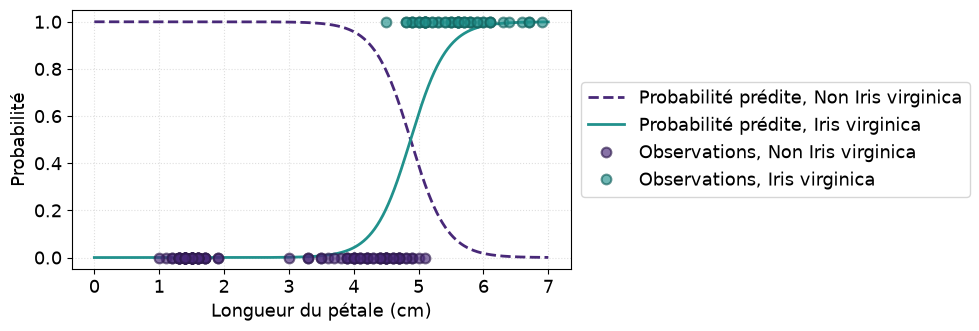

In [49]:
# Générer des valeurs de 'petal length' pour prédire les probabilités
X_new = np.linspace(0, 7, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

fig, ax = plt.subplots(figsize=(6, 3.5))

# Tracer les probabilités de chaque classe
ax.plot(X_new, y_proba[:, 0], color=VIOLET,
        linestyle="--", linewidth=2,
        label="Probabilité prédite, Non Iris virginica")
ax.plot(X_new, y_proba[:, 1], color=SARCELLE,
        linestyle="-", linewidth=2,
        label="Probabilité prédite, Iris virginica")

# Tracer les individus pour chaque classe
for val, nom, coul in [(0, "Non Iris virginica", VIOLET),
                       (1, "Iris virginica", SARCELLE)]:
    ax.plot(X[y == val], y[y == val], "o", color=coul, alpha=0.65,
            markersize=7, markeredgewidth=1.5, markeredgecolor=BORD[coul],
            label=f"Observations, {nom}")

# Paramètres des axes
ax.set_xlabel("Longueur du pétale (cm)")
ax.set_ylabel("Probabilité")
ax.grid(alpha=0.4, linestyle=":")

plt.tight_layout()

# légende à l'extérieur, les libellés sont longs
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureLogitPetalLength")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.20 : Calcul de la valeur de la variable au seuil de décision</h3>

In [50]:
# Récupérer les paramètres du modèle
theta_0 = log_reg.intercept_[0]  
theta_1 = log_reg.coef_[0][0]   

# Calcul de la longueur du pétale 
petal_length_decision_threshold = -theta_0 / theta_1

print(f"Longueur du pétale au seuil de décision : "
      f"{petal_length_decision_threshold:.4f}")

Longueur du pétale au seuil de décision : 4.8759


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.21 : Régression logistique à deux variables et calcul des probabilités sur une grille du plan des caractéristiques</h3>

In [51]:
# Deux variables explicatives : longueur et largeur du pétale
X = iris_df[['petal length (cm)', 'petal width (cm)']].values
y = (iris_df['target'] == 2).astype(int).values

# Entraînement du modèle à deux variables
log_reg2 = LogisticRegression(random_state=42)
log_reg2.fit(X, y)

# Grille de points couvrant le plan des caractéristiques
x1, x2 = np.meshgrid(np.linspace(2.5, 7, 500),
                     np.linspace(0, 3, 200))
X_new = np.c_[x1.ravel(), x2.ravel()]

# Probabilité de la classe Iris virginica en chaque point de la grille
proba = log_reg2.predict_proba(X_new)[:, 1].reshape(x1.shape)

<h3><span style="font-size: 30px">&#127924;</span> Figure : Frontière de décision de la régression logistique à deux variables</h3>

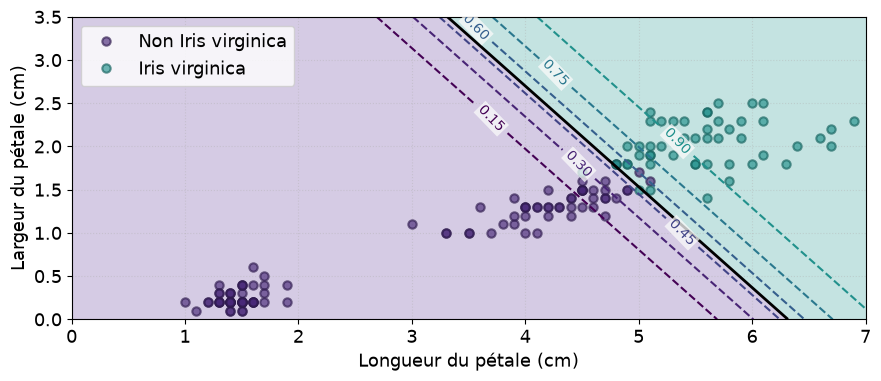

In [52]:
# Frontière de décision et lignes de niveau de probabilité
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(9, 4))

# Grille d'affichage étendue couvrant toute la surface du graphique
x1_aff, x2_aff = np.meshgrid(np.linspace(0, 7, 500),
                             np.linspace(0, 3.5, 200))
proba_aff = log_reg2.predict_proba(
    np.c_[x1_aff.ravel(), x2_aff.ravel()])[:, 1].reshape(x1_aff.shape)

# Zones de décision en arrière-plan (classe prédite), teintes pâles assorties aux classes
zones = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE]])
ax.contourf(x1_aff, x2_aff, (proba_aff >= 0.5).astype(int), cmap=zones)

# Observations des deux classes
for val, nom, coul in [(0, "Non Iris virginica", VIOLET),
                       (1, "Iris virginica", SARCELLE)]:
    idx = (y == val)
    ax.plot(X[idx, 0], X[idx, 1], "o", color=coul, #markersize=7,
            markeredgewidth=1.5, markeredgecolor=BORD[coul],
            label=nom, alpha=0.65)

# Palette viridis tronquée : on écarte les jaunes, peu visibles sur fond pâle
viridis_sombre = LinearSegmentedColormap.from_list(
    'viridis_sombre', plt.cm.viridis(np.linspace(0, 0.5, 256)))

# Lignes de niveau de probabilité (pointillés) et frontière de décision (trait plein)
niveaux = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]
cs = ax.contour(x1_aff, x2_aff, proba_aff, levels=niveaux,
                linestyles='--', cmap=viridis_sombre, linewidths=1.5)
clabels = ax.clabel(cs, inline=True, fontsize=10, fmt='%.2f')

# Fond clair derrière chaque étiquette, pour la détacher du dégradé
for label in clabels:
    label.set_bbox(dict(facecolor='#FAFAFA', edgecolor='none',
                        pad=1, alpha=0.75))

ax.contour(x1_aff, x2_aff, proba_aff, levels=[0.5], colors='black',
           linewidths=2)

# Paramètres des axes
ax.set_xlabel('Longueur du pétale (cm)')
ax.set_ylabel('Largeur du pétale (cm)')
ax.set_xlim(0, 7)
ax.set_ylim(0, 3.5)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc="upper left")

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4_FigureFrontieres2Class")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.22 : Évaluation du modèle de régression logistique par partition apprentissage/test et validation croisée</h3>

In [53]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, log_loss)

# Retour au modèle Virginica à une variable : longueur du pétale
X = iris_df[['petal length (cm)']].values
y = (iris_df['target'] == 2).astype(int).values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          stratify=y, 
                                          random_state=42)
modele = LogisticRegression().fit(X_tr, y_tr)
y_pred = modele.predict(X_te)

# Validation croisée 5-fold sur l'ensemble des données
scores = cross_val_score(LogisticRegression(), X, y, cv=5,
                         scoring="accuracy")

In [54]:
# Affichage des résultats
print("=" * 65)
print("Exactitude (test) = {:.4f}".format(accuracy_score(y_te, y_pred)))
print("Précision         = {:.4f}        Rappel = {:.4f}".format(
    precision_score(y_te, y_pred), recall_score(y_te, y_pred)))
print("F1-score          = {:.4f}".format(f1_score(y_te, y_pred)))
print("Perte log (test)  = {:.4f}        Perte log (entraînement) = {:.4f}".format(
    log_loss(y_te, modele.predict_proba(X_te)),
    log_loss(y_tr, modele.predict_proba(X_tr))))
print("-" * 65)
print("Validation croisée 5-fold, exactitude par bloc :")
print("  " + "   ".join("{:.4f}".format(s) for s in scores))
print("  moyenne = {:.4f}        écart-type = {:.4f}".format(scores.mean(),
                                                             scores.std()))
print("=" * 65)

Exactitude (test) = 0.9333
Précision         = 0.9000        Rappel = 0.9000
F1-score          = 0.9000
Perte log (test)  = 0.1880        Perte log (entraînement) = 0.1550
-----------------------------------------------------------------
Validation croisée 5-fold, exactitude par bloc :
  0.9667   1.0000   0.9333   0.8667   0.9667
  moyenne = 0.9467        écart-type = 0.0452


In [55]:
# Prédictions sur les ensembles d'entraînement et de test
y_pred_tr = modele.predict(X_tr)
y_pred_te = modele.predict(X_te)

# Calcul des métriques
acc_tr = accuracy_score(y_tr, y_pred_tr)
acc_te = accuracy_score(y_te, y_pred_te)

prec_tr = precision_score(y_tr, y_pred_tr)
prec_te = precision_score(y_te, y_pred_te)

rec_tr = recall_score(y_tr, y_pred_tr)
rec_te = recall_score(y_te, y_pred_te)

f1_tr = f1_score(y_tr, y_pred_tr)
f1_te = f1_score(y_te, y_pred_te)

log_tr = log_loss(y_tr, modele.predict_proba(X_tr))
log_te = log_loss(y_te, modele.predict_proba(X_te))

# Affichage des résultats

print("=" * 51)
print("Comparaison entraînement / test")
print("=" * 51)
print(f"{'Métrique':<18}{'Entraînement':<18}{'Test'}")
print(f"{'Exactitude':<18}{acc_tr:<18.4f}{acc_te:.4f}")
print(f"{'Précision':<18}{prec_tr:<18.4f}{prec_te:.4f}")
print(f"{'Rappel':<18}{rec_tr:<18.4f}{rec_te:.4f}")
print(f"{'F1-score':<18}{f1_tr:<18.4f}{f1_te:.4f}")
print(f"{'Perte log':<18}{log_tr:<18.4f}{log_te:.4f}")

print("=" * 51)
print("Validation croisée (5-fold)")
print("=" * 51)
entetes = [f"Fold {i}" for i in range(1, len(scores) + 1)]
print("Folds".ljust(13) + "".join(e.ljust(8) for e in entetes))
print("Exactitude".ljust(13) + "".join(f"{v:.4f}".ljust(8) for v in scores))
print("-" * 51)
print(" " * 28 + f"{'Moyenne':<12}{scores.mean():.4f}")
print(" " * 28 + f"{'Écart-type':<12}{scores.std():.4f}")
print("=" * 51)

Comparaison entraînement / test
Métrique          Entraînement      Test
Exactitude        0.9583            0.9333
Précision         0.9268            0.9000
Rappel            0.9500            0.9000
F1-score          0.9383            0.9000
Perte log         0.1550            0.1880
Validation croisée (5-fold)
Folds        Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  
Exactitude   0.9667  1.0000  0.9333  0.8667  0.9667  
---------------------------------------------------
                            Moyenne     0.9467
                            Écart-type  0.0452


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.23 : Régression logistique multinomiale</h3>

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Préparation des données et utilisation de 'petal length (cm)' et 'petal width (cm)' comme variables explicatives
X = iris["data"][:, 2:4]

# La variable cible est l'espèce de l'Iris (0, 1 ou 2)
y = iris["target"]

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Standardisation des données pour faciliter l'optimisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Création et entraînement du modèle de régression logistique multinomiale
softmax_reg = LogisticRegression(solver="lbfgs")
softmax_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [57]:
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
classes = ["Setosa (0)", "Versicolor (1)", "Virginica (2)"]
entetes = [f"θ{str(i).translate(SUP)} ({nom})" for i, nom in enumerate(["biais", "longueur", "largeur"])]

# Paramètres du modèle de régression softmax
print("=" * 60)
print("Paramètres du modèle de régression softmax")
print("=" * 60)
print(f"{'Classe':<16}{entetes[0]:<16}{entetes[1]:<16}{entetes[2]}")
print("-" * 60)
for k, nom in enumerate(classes):
    print(f"{nom:<16}{softmax_reg.intercept_[k]:<16.6f}{softmax_reg.coef_[k][0]:<16.6f}{softmax_reg.coef_[k][1]:.6f}")
print("=" * 60)

Paramètres du modèle de régression softmax
Classe          θ₀ (biais)      θ₁ (longueur)   θ₂ (largeur)
------------------------------------------------------------
Setosa (0)      -0.580901       -2.426069       -2.148335
Versicolor (1)  1.848060        0.241222        -0.507701
Virginica (2)   -1.267159       2.184847        2.656036


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.24 : Rapport de la régression logistique multinomiale</h3>

In [58]:
from sklearn.metrics import classification_report

# Prédictions sur l'ensemble de test (données normalisées)
y_pred = softmax_reg.predict(X_test_scaled)

# Évaluer le modèle
report = classification_report(y_test, y_pred)

# Afficher les résultats
print("\nRapport de classification:")
print(report)


Rapport de classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



<h3><span style="font-size: 30px">&#127924;</span> Figure : Frontières de décision de la régression softmax</h3>

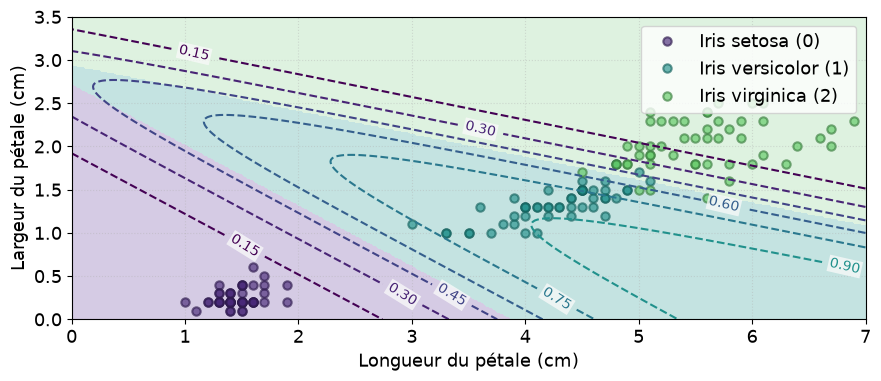

In [59]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# Génération d'une grille dans les unités originales (cm)
x0_grid, x1_grid = np.meshgrid(
    np.linspace(0, 7, 500),
    np.linspace(0, 3.5, 200)
)

X_grille = np.c_[x0_grid.ravel(), x1_grid.ravel()]

# Standardisation de la grille avec le scaler appris sur l'ensemble d'entraînement
X_grille_scaled = scaler.transform(X_grille)

# Prédiction des probabilités et des classes avec le modèle déjà entraîné
probabilites_classe = softmax_reg.predict_proba(X_grille_scaled)
predictions_classe = softmax_reg.predict(X_grille_scaled)

# Mise en forme pour la visualisation
probabilite_versicolor = probabilites_classe[:, 1].reshape(x0_grid.shape)
frontiere_decision = predictions_classe.reshape(x0_grid.shape)

# Configuration de la figure
fig, ax = plt.subplots(figsize=(9, 4))

# Zones de décision en arrière-plan, teintes pâles assorties aux classes
couleurs_zones = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]])
ax.contourf(x0_grid, x1_grid, frontiere_decision, cmap=couleurs_zones)

# Observations des trois classes
for val, nom, coul in [(0, "Iris setosa (0)", VIOLET),
                       (1, "Iris versicolor (1)", SARCELLE),
                       (2, "Iris virginica (2)", VERT)]:
    idx = (y == val)
    ax.plot(X[idx, 0], X[idx, 1], "o", color=coul, #markersize=7,
            markeredgewidth=1.5, markeredgecolor=BORD[coul],
            label=nom, alpha=0.65)

# Palette viridis tronquée : on écarte les jaunes, peu visibles sur fond pâle
viridis_sombre = LinearSegmentedColormap.from_list(
    'viridis_sombre', plt.cm.viridis(np.linspace(0, 0.5, 256)))

# Lignes de niveau de probabilité pour Iris versicolor
niveaux = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]
contours = ax.contour(x0_grid, x1_grid, probabilite_versicolor,
                      levels=niveaux, linestyles="--",
                      cmap=viridis_sombre, linewidths=1.5)

clabels = ax.clabel(contours, inline=True, fontsize=10, fmt='%.2f')
for label in clabels:
    label.set_bbox(dict(facecolor='#FAFAFA', edgecolor='none',
                        pad=1, alpha=0.75))

# Paramètres des axes
ax.set_xlabel("Longueur du pétale (cm)")
ax.set_ylabel("Largeur du pétale (cm)")
ax.set_xlim(0, 7)
ax.set_ylim(0, 3.5)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc="upper right")

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap4-SoftmaxFrontiere")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.25 : Ajustement du modèle de régression linéaire avec statsmodels et rapport statistique complet</h3>

In [60]:
import statsmodels.api as sm

# Retour au jeu de données linéaires du début du chapitre
np.random.seed(42)
X = np.random.rand(100, 1)
y = 3 * X + 2 + np.random.randn(100, 1)

# statsmodels n'ajoute pas le vecteur unitaire : il faut le fournir
X_b = sm.add_constant(X)

modele = sm.OLS(y, X_b).fit()
print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     68.69
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           6.14e-13
Time:                        23:15:51   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2151      0.170     13.008      0.0

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 4.26 : Ajustement de la régression logistique avec statsmodels et rapport statistique</h3>

In [61]:
import statsmodels.api as sm

# Retour au modèle à une variable : longueur du pétale
X = iris_df[['petal length (cm)']].values
y = (iris_df['target'] == 2).astype(int).values

# statsmodels n'ajoute pas le vecteur unitaire : il faut le fournir
X_b = sm.add_constant(X)

modele = sm.Logit(y, X_b).fit()
print(modele.summary())

Optimization terminated successfully.
         Current function value: 0.111440
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  150
Model:                          Logit   Df Residuals:                      148
Method:                           MLE   Df Model:                            1
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.8249
Time:                        23:15:51   Log-Likelihood:                -16.716
converged:                       True   LL-Null:                       -95.477
Covariance Type:            nonrobust   LLR p-value:                 3.936e-36
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -43.7809     11.110     -3.941      0.000     -65.556     -22.006
x1             9.0020      2

<hr style='border-top:4px solid #1F77B4;'>